# Validación de actividad humana

Este notebook construye o reutiliza la capa estática basada en OpenStreetMap, valida sus tres variables y las representa sobre Galicia. La descarga solo ocurre si no existe el extracto Shapefile versionado en `data/raw/human_activity/`.

Variables: `distance_to_road_m`, `road_length_km` y `distance_to_residential_area_m`. No son variables diarias: se calculan una vez por celda de 1 km.

In [4]:
import sys
from pathlib import Path

# Permite ejecutarlo desde PyCharm (raíz) y desde Jupyter (notebooks/).
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from src.config import (
    GRID_PATH,
    HUMAN_ACTIVITY_CUBE_PATH,
    HUMAN_ACTIVITY_RAW_DIR,
    SPATIAL_CUBE_PATH,
)
from src.geospatial.human_activity import (
    OSM_GALICIA_2022_URL,
    construir_capa_actividad_humana,
)

print(f'Fuente fija: {OSM_GALICIA_2022_URL}')
print(f'Archivo local: {HUMAN_ACTIVITY_RAW_DIR}')

Fuente fija: https://download.geofabrik.de/europe/spain/galicia-220101-free.shp.zip
Archivo local: C:\Users\alfon\PycharmProjects\Sistema-deteccion-incendios\data\raw\human_activity


In [5]:
# Descarga el extracto OSM solo si falta y genera la capa estática.
construir_capa_actividad_humana(
    grid_path=GRID_PATH,
    spatial_cube_path=SPATIAL_CUBE_PATH,
    output_path=HUMAN_ACTIVITY_CUBE_PATH,
    raw_dir=HUMAN_ACTIVITY_RAW_DIR,
)
print(f'✓ Capa creada: {HUMAN_ACTIVITY_CUBE_PATH}')

KeyboardInterrupt: 

In [3]:
with xr.open_dataset(SPATIAL_CUBE_PATH) as spatial, xr.open_dataset(HUMAN_ACTIVITY_CUBE_PATH) as human:
    active = spatial['is_galicia'].astype(bool)
    print(human)
    for variable in human.data_vars:
        values = human[variable].where(active)
        print(
            f'{variable}: min={float(values.min()):.2f}, '
            f'mediana={float(values.median()):.2f}, max={float(values.max()):.2f}'
        )
    assert set(human.data_vars) == {
        'distance_to_road_m',
        'road_length_km',
        'distance_to_residential_area_m',
    }
    # Fuera de Galicia se conserva NaN deliberadamente; solo validamos la máscara activa.
    for variable in human.data_vars:
        values = human[variable]
        assert int((values.isnull() & active).sum()) == 0
        assert (values.values[active.values] >= 0).all()
print('✓ Esquema, cobertura y rangos válidos.')

<xarray.Dataset> Size: 552kB
Dimensions:                         (y: 225, x: 203)
Coordinates:
  * y                               (y) int64 2kB 2245000 2246000 ... 2469000
  * x                               (x) int64 2kB 2760000 2761000 ... 2962000
Data variables:
    distance_to_road_m              (y, x) float32 183kB ...
    road_length_km                  (y, x) float32 183kB ...
    distance_to_residential_area_m  (y, x) float32 183kB ...
Attributes:
    title:    Human activity variables
    source:   OpenStreetMap via Geofabrik, Galicia snapshot 2022-01-01
    module:   human_activity
    crs:      EPSG:3035
distance_to_road_m: min=0.00, mediana=0.00, max=7722.79
road_length_km: min=0.00, mediana=2.01, max=33.55
distance_to_residential_area_m: min=0.00, mediana=0.00, max=8007.90
✓ Esquema, cobertura y rangos válidos.


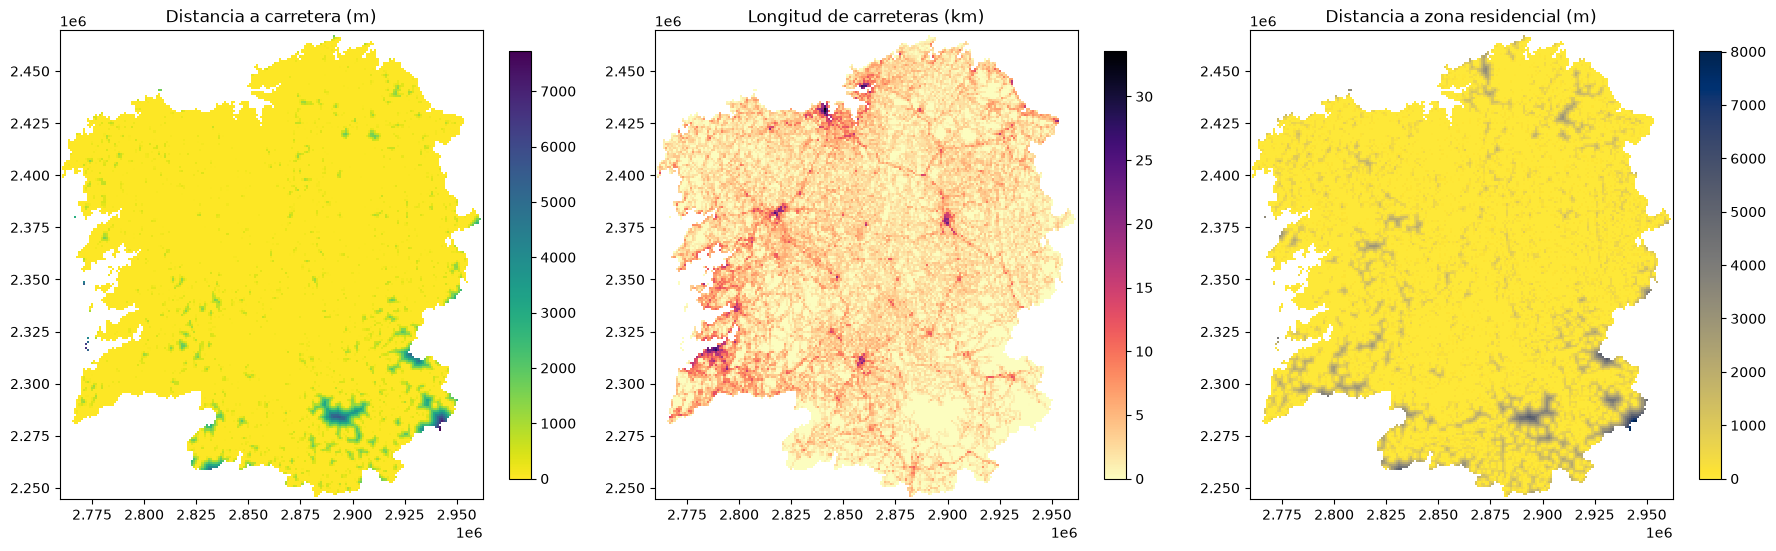

In [4]:
with xr.open_dataset(SPATIAL_CUBE_PATH) as spatial, xr.open_dataset(HUMAN_ACTIVITY_CUBE_PATH) as human:
    active = spatial['is_galicia'].astype(bool)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    plots = [
        ('distance_to_road_m', 'Distancia a carretera (m)', 'viridis_r'),
        ('road_length_km', 'Longitud de carreteras (km)', 'magma_r'),
        ('distance_to_residential_area_m', 'Distancia a zona residencial (m)', 'cividis_r'),
    ]
    for ax, (variable, title, cmap) in zip(axes, plots, strict=True):
        image = human[variable].where(active).plot(ax=ax, cmap=cmap, add_colorbar=False)
        fig.colorbar(image, ax=ax, shrink=.75)
        ax.set(title=title, xlabel='', ylabel='', facecolor='white')
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

## Integración final

Al ejecutar `python -m src.workflow`, la capa se crea automáticamente si falta. Para recalcularla con el mismo extracto OSM local, usar `--rebuild-human-activity`. Después, el NetCDF final y los Parquet incluyen las tres variables como predictores estáticos.

## Validación visual del contrato final

Esta celda comprueba que la variable existe en el cubo final y la representa sobre la máscara de Galicia con fondo blanco.

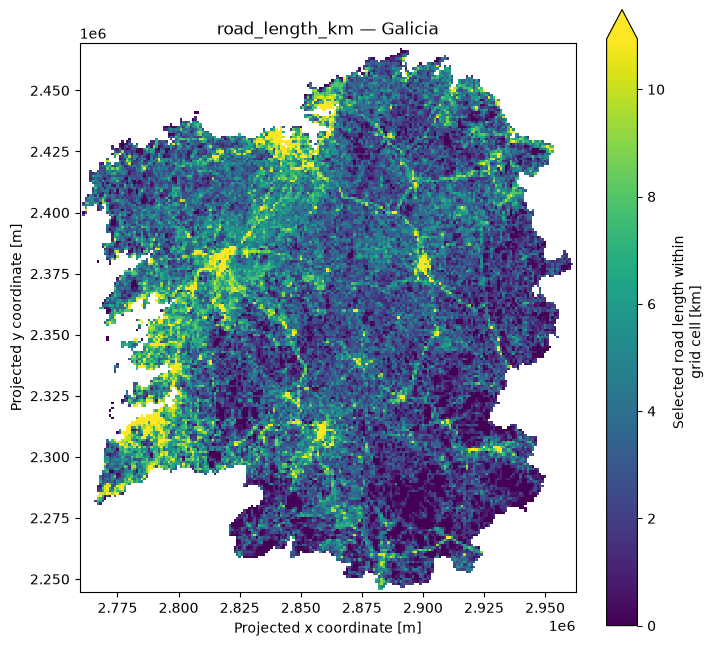

In [6]:
import matplotlib.pyplot as plt
import xarray as xr
from src.config import DATACUBE_PATH

variable = "road_length_km"
with xr.open_dataset(DATACUBE_PATH) as cube:
    data = cube[variable]
    if "time" in data.dims:
        data = data.isel(time=0)
    data = data.where(cube["is_galicia"] == 1)
    assert data.notnull().any(), f"{variable} no contiene valores válidos"
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")
    data.plot(ax=ax, cmap="viridis", robust=True, add_colorbar=True)
    ax.set(title=f"{variable} — Galicia", facecolor="white")
    ax.set_aspect("equal")
    plt.show()

## Validación de las variables nuevas de actividad humana

Esta sección valida el contrato final: las longitudes por categoría deben sumar la longitud total y las fracciones de ocupación deben estar entre 0 y 1. Las variables de distancia no se almacenan en el cubo final por su saturación a escala de 1 km.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from src.config import DATACUBE_PATH

HUMAN_VARIABLES = [
    "road_length_km",
    "road_length_main_km",
    "road_length_local_km",
    "road_length_track_km",
    "road_length_other_km",
    "residential_area_fraction",
    "building_area_fraction",
]

with xr.open_dataset(DATACUBE_PATH) as cube:
    active = cube["is_galicia"].astype(bool)
    missing = sorted(set(HUMAN_VARIABLES) - set(cube.data_vars))
    assert not missing, f"Variables de actividad humana ausentes: {missing}"
    values = {name: cube[name].where(active).values for name in HUMAN_VARIABLES}
    total = (
        values["road_length_main_km"]
        + values["road_length_local_km"]
        + values["road_length_track_km"]
        + values["road_length_other_km"]
    )
    error = np.nanmax(np.abs(values["road_length_km"] - total))
    assert error < 1e-4, f"La longitud total no coincide con sus categorías: {error} km"
    for name in ("residential_area_fraction", "building_area_fraction"):
        assert np.nanmin(values[name]) >= 0
        assert np.nanmax(values[name]) <= 1

    summary = {
        name: {
            "mínimo": float(np.nanmin(value)),
            "media": float(np.nanmean(value)),
            "p99": float(np.nanpercentile(value, 99)),
            "máximo": float(np.nanmax(value)),
            "ceros (%)": float((value[active.values] == 0).mean() * 100),
        }
        for name, value in values.items()
    }

print(f"✓ Las longitudes suman road_length_km (error máximo: {error:.6f} km).")
print("✓ Las fracciones residencial y de edificios están acotadas entre 0 y 1.")
summary


✓ Las longitudes suman road_length_km (error máximo: 0.000004 km).
✓ Las fracciones residencial y de edificios están acotadas entre 0 y 1.


{'road_length_km': {'mínimo': 0.0,
  'media': 3.6673507690429688,
  'p99': 12.99255084991455,
  'máximo': 33.64179611206055,
  'ceros (%)': 5.766697071044897},
 'road_length_main_km': {'mínimo': 0.0,
  'media': 0.33957332372665405,
  'p99': 4.0068535804748535,
  'máximo': 10.856816291809082,
  'ceros (%)': 76.0379716901456},
 'road_length_local_km': {'mínimo': 0.0,
  'media': 2.1943602561950684,
  'p99': 9.581276893615723,
  'máximo': 27.43018913269043,
  'ceros (%)': 16.17850748285531},
 'road_length_track_km': {'mínimo': 0.0,
  'media': 1.133417010307312,
  'p99': 5.583625793457031,
  'máximo': 13.14638900756836,
  'ceros (%)': 25.88763893111719},
 'road_length_other_km': {'mínimo': 0.0,
  'media': 0.0,
  'p99': 0.0,
  'máximo': 0.0,
  'ceros (%)': 100.0},
 'residential_area_fraction': {'mínimo': 0.0,
  'media': 0.018120789900422096,
  'p99': 0.3691154718399048,
  'máximo': 1.0,
  'ceros (%)': 76.04810648288908},
 'building_area_fraction': {'mínimo': 0.0,
  'media': 0.002600774867460

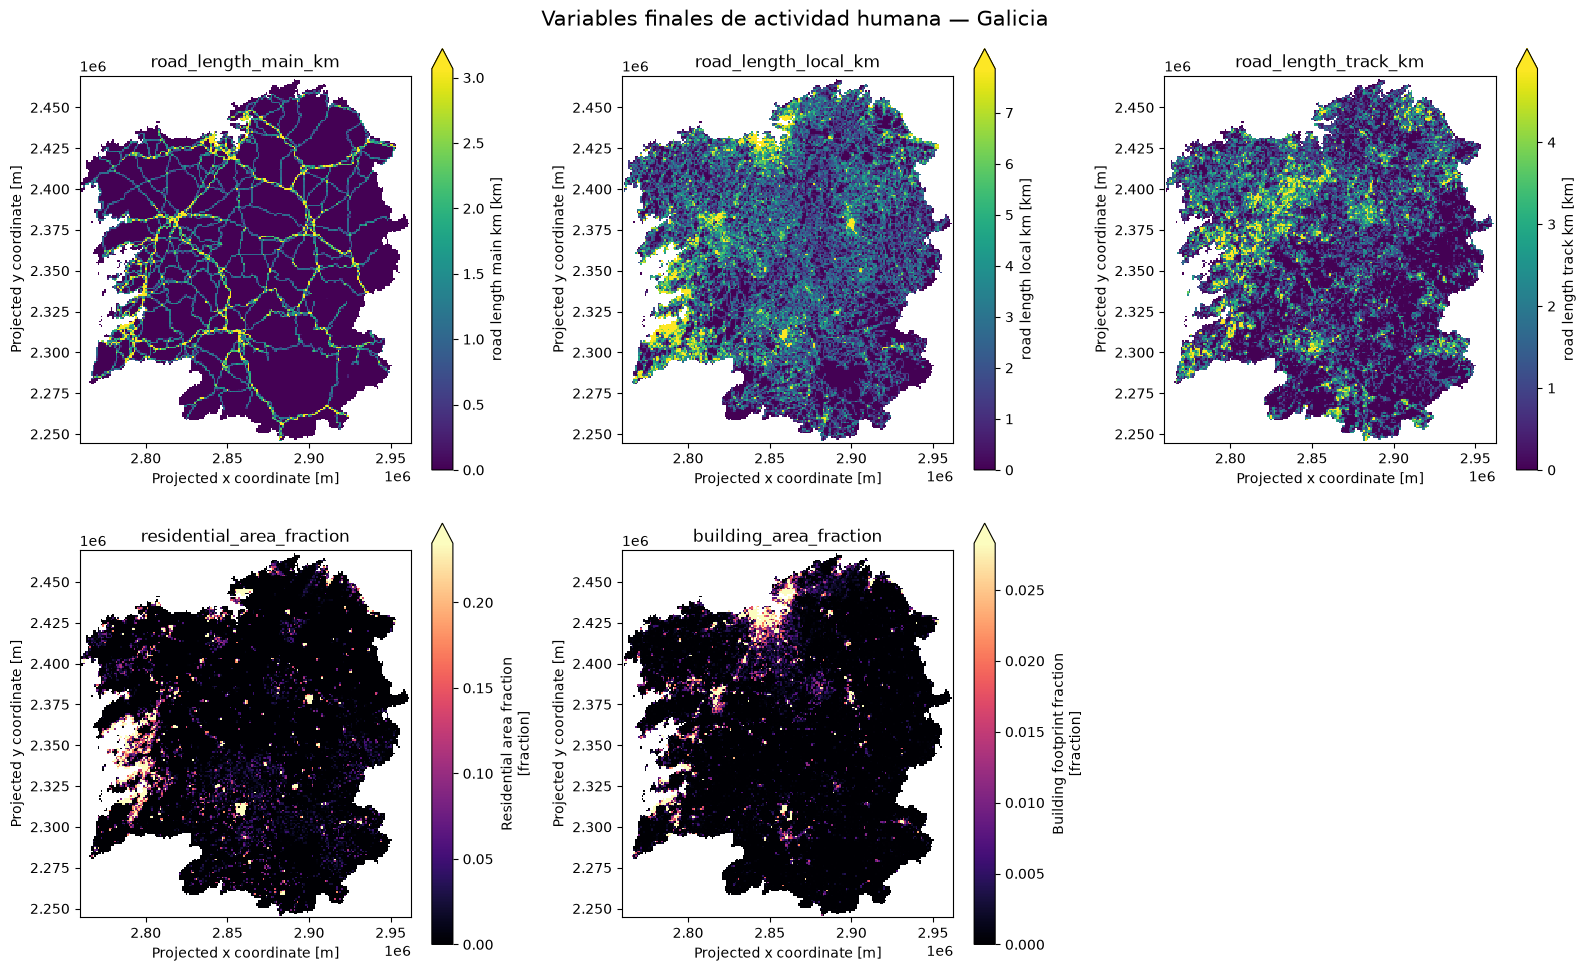

In [8]:
with xr.open_dataset(DATACUBE_PATH) as cube:
    active = cube["is_galicia"] == 1
    variables = [
        ("road_length_main_km", "viridis"),
        ("road_length_local_km", "viridis"),
        ("road_length_track_km", "viridis"),
        ("residential_area_fraction", "magma"),
        ("building_area_fraction", "magma"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor="white")
    for ax, (name, cmap) in zip(axes.flat, variables, strict=False):
        cube[name].where(active).plot(ax=ax, cmap=cmap, robust=True, add_colorbar=True)
        ax.set(title=name, facecolor="white")
        ax.set_aspect("equal")
    axes.flat[-1].axis("off")
    fig.suptitle("Variables finales de actividad humana — Galicia", fontsize=15)
    plt.tight_layout()
    plt.show()
